In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/bencarson/gemma-4-31b-emotion-extraction/activations_pooled_31b.pkl
/kaggle/input/notebooks/bencarson/gemma-4-31b-emotion-extraction/__results__.html
/kaggle/input/notebooks/bencarson/gemma-4-31b-emotion-extraction/__notebook__.ipynb
/kaggle/input/notebooks/bencarson/gemma-4-31b-emotion-extraction/__output__.json
/kaggle/input/notebooks/bencarson/gemma-4-31b-emotion-extraction/custom.css
/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt


In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [3]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
import os, glob

PHASE2_PKL_CANDIDATES = [
    # Kaggle slug derived from notebook title "Gemma 4 Emotions Phase 2"
    "/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2-31b/activations_pooled_31b.pkl",
    # Fallback slugs in case title differs
    "/kaggle/input/notebooks/bencarson/gemma-4-phase2-31b-pooled-extraction/activations_pooled_31b.pkl",
    "/kaggle/input/gemma-4-emotions-phase-2-31b/activations_pooled_31b.pkl",
    "/kaggle/input/gemma-4-phase2-31b-pooled-extraction/activations_pooled_31b.pkl",
    "/kaggle/working/activations_pooled_31b.pkl",
]
PHASE1_PKL = (
    "/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction"
    "/emotions_phase1/activations.pkl"
)
NRC_PATH = "/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt"

# Dense layer sweep (Phase 2): two valence peaks at layers 6-9 and 16-22.
# Layer 8 (local) is the global valence optimum (r=0.777); layer 18 (r=0.760) is the late-peak optimum.
# Arousal peaks at layer 25 (r=0.485) — val and aro have different optimal layers.
# Provisional from Phase 2 sparse sweep (every-6-layer). Run Cell 8 dense sweep
# to confirm — this highlights the provisional layer in the sweep table.
LAYER = 22  # Confirmed: 31B valence-optimal (dense sweep PC1 r=0.786, peak of L17-L23 cluster)

# Auto-detect: try known paths, then glob for any activations_pooled_31b.pkl in /kaggle/input
ACTS_PATH = next((p for p in PHASE2_PKL_CANDIDATES if os.path.exists(p)), None)
if ACTS_PATH is None:
    hits = glob.glob("/kaggle/input/**/activations_pooled_31b.pkl", recursive=True)
    ACTS_PATH = hits[0] if hits else PHASE1_PKL

print(f"Loading activations from: {ACTS_PATH}")
print(f"Analysis layer: {LAYER}")

with open(ACTS_PATH, "rb") as f:
    saved = pickle.load(f)

resid_acts = saved["resid"]  # {emotion: [n_stories, n_layers, d_model]}
meta = saved.get("meta", {})
if meta:
    print(f"  extraction={meta.get('extraction')}  "
          f"pool_start={meta.get('emotion_pool_start')}  "
          f"n_neutral={meta.get('n_neutral')}")

nrc = pd.read_csv(NRC_PATH, sep="\t", header=0,
                  names=["word", "valence", "arousal", "dominance"])
nrc = nrc.drop_duplicates("word").set_index("word")


Loading activations from: /kaggle/input/notebooks/bencarson/gemma-4-31b-emotion-extraction/activations_pooled_31b.pkl
Analysis layer: 6
  extraction=mean_pool  pool_start=50  n_neutral=100


In [4]:
# ── Cell 3: Compute mean directions at layer 25 ──────────────────────────────
# Centering: Tim Duffy's approach — subtract the global mean of all emotion
# means rather than an external neutral baseline. Neutral stories are reserved
# solely for PCA denoising (Cell 4b). This keeps direction geometry entirely
# within the emotion subspace.

neutral_stories = resid_acts["__neutral__"]        # [n_neutral, n_layers, d_model]
n_neutral = neutral_stories.shape[0]

# Compute per-emotion means at the analysis layer
emotion_names, emotion_means = [], []
for name, arr in resid_acts.items():
    if name == "__neutral__":
        continue
    emotion_means.append(arr[:, LAYER, :].mean(axis=0))  # [d_model]
    emotion_names.append(name)

emotion_means = np.stack(emotion_means)  # [n_emotions, d_model]

# Global mean (mean of all emotion means — Tim's approach)
global_mean = emotion_means.mean(axis=0)  # [d_model]

# Neutral mean (for reference / comparison with old approach)
neutral_mean = neutral_stories[:, LAYER, :].mean(axis=0)  # [d_model]

# Emotion directions = mean - global_mean
directions = emotion_means - global_mean  # [n_emotions, d_model]

print(f"Direction matrix: {directions.shape}")
print(f"Neutral stories:  {n_neutral}")
print(f"Centering: global mean of {len(emotion_names)} emotion means")


Direction matrix: (174, 5376)
Neutral stories:  100
Centering: global mean of 174 emotion means


In [5]:
# ── Cell 4: Match to NRC-VAD ─────────────────────────────────────────────────
def lookup_vad(name):
    word = name.replace('_', ' ').lower()
    if word in nrc.index:
        return nrc.loc[word, ['valence', 'arousal', 'dominance']].values.astype(float)
    first = word.split()[0]
    if first in nrc.index:
        return nrc.loc[first, ['valence', 'arousal', 'dominance']].values.astype(float)
    return None

vad_rows, kept_names, kept_dirs, missing = [], [], [], []
for name, direction in zip(emotion_names, directions):
    row = lookup_vad(name)
    if row is not None:
        vad_rows.append(row)
        kept_names.append(name)
        kept_dirs.append(direction)
    else:
        missing.append(name)

if missing:
    print(f"No NRC entry for: {missing}")

vad  = np.array(vad_rows)   # [N, 3]  — valence, arousal, dominance
dirs = np.array(kept_dirs)  # [N, 1536]
print(f"Matched {len(kept_names)}/{len(emotion_names)} emotions")


No NRC entry for: ['energized', 'insulted', 'stimulated']
Matched 171/174 emotions


In [6]:
# ── Cell 4b: Neutral-subspace denoising + comparison PCA ─────────────────────
# Projects out the top-k PCs of neutral activations from emotion directions.
# Neutral stories come from resid_acts['__neutral__']:
#   Phase 2 pkl → 100 mean-pooled neutral stories  (preferred)
#   Phase 1 pkl → 10 last-token neutral stories    (fallback)
#
# The denoising isolates emotion-specific variance by removing directions that
# are active even during emotionally-neutral processing.

VARIANCE_THRESHOLD = 0.50

neutral_raw_all = neutral_stories[:, LAYER, :]  # [n_neutral, d_model]
print(f"Neutral activations for denoising: {neutral_raw_all.shape}")

# Fit PCA on neutral activations
pca_neutral = PCA()
pca_neutral.fit(neutral_raw_all)
cumvar_n = np.cumsum(pca_neutral.explained_variance_ratio_)
n_n_pcs  = int(np.searchsorted(cumvar_n, VARIANCE_THRESHOLD) + 1)
print(f"\nNeutral PCA: {n_n_pcs} PC(s) → {cumvar_n[n_n_pcs-1]*100:.1f}% of neutral variance")
for i in range(n_n_pcs):
    print(f"  PC{i+1}: {pca_neutral.explained_variance_ratio_[i]*100:.1f}%")

neutral_comps = pca_neutral.components_[:n_n_pcs]  # [k, d_model]

def denoise_vec(vec, comps):
    return vec - comps.T @ (comps @ vec)

dirs_denoised = np.array([denoise_vec(d, neutral_comps) for d in dirs])
print(f"\nDirs: {dirs.shape} → denoised: {dirs_denoised.shape}")

# Comparison table: raw vs denoised
def show_pca_table(D, vad_arr, label, n_show=10):
    pca_t    = PCA(n_components=min(n_show, len(D)))
    scores_t = pca_t.fit_transform(D)
    print(f"\n── {label} ──")
    print(f"{'PC':>4}  {'var%':>6}  {'valence_r':>12}  {'arousal_r':>10}  {'dominance_r':>12}")
    for i in range(pca_t.n_components_):
        rv, pv = stats.pearsonr(scores_t[:, i], vad_arr[:, 0])
        ra, _  = stats.pearsonr(scores_t[:, i], vad_arr[:, 1])
        rd, _  = stats.pearsonr(scores_t[:, i], vad_arr[:, 2])
        sig = "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else "  "))
        print(f"{i+1:>4}  {pca_t.explained_variance_ratio_[i]*100:>5.1f}%"
              f"  {rv:>+10.3f}{sig:<3s}  {ra:>+10.3f}  {rd:>+12.3f}")
    return pca_t, scores_t

pca_raw, scores_raw = show_pca_table(dirs,          vad, "Raw  (global-mean centred)")
pca_den, scores_den = show_pca_table(dirs_denoised, vad,
                                     f"Denoised  ({n_n_pcs}-PC neutral subspace projected out, n={len(neutral_raw_all)})")


Neutral activations for denoising: (100, 5376)

Neutral PCA: 12 PC(s) → 51.1% of neutral variance
  PC1: 10.5%
  PC2: 7.1%
  PC3: 5.4%
  PC4: 4.3%
  PC5: 4.1%
  PC6: 3.7%
  PC7: 3.3%
  PC8: 2.8%
  PC9: 2.8%
  PC10: 2.5%
  PC11: 2.3%
  PC12: 2.1%

Dirs: (171, 5376) → denoised: (171, 5376)

── Raw  (global-mean centred) ──
  PC    var%     valence_r   arousal_r   dominance_r
   1   14.1%      +0.675***      -0.217        +0.516
   2    9.3%      +0.012         -0.204        -0.017
   3    7.8%      -0.030         -0.077        -0.058
   4    6.4%      -0.138         +0.013        -0.173
   5    4.3%      +0.387***      -0.001        +0.162
   6    3.9%      +0.169*        +0.278        +0.215
   7    3.3%      -0.070         -0.201        -0.132
   8    2.9%      -0.088         +0.230        +0.214
   9    2.8%      +0.077         +0.325        +0.161
  10    2.5%      -0.112         +0.296        -0.031

── Denoised  (12-PC neutral subspace projected out, n=100) ──
  PC    var%     vale

In [7]:
# ── Cell 5: PCA ──────────────────────────────────────────────────────────────
N_PCS = 50
pca    = PCA(n_components=N_PCS)
scores = pca.fit_transform(dirs_denoised)  # [N, 50]

cumvar = np.cumsum(pca.explained_variance_ratio_)
for k in [3, 5, 10, 16, 20, 36]:
    if k <= N_PCS:
        print(f"  {k:2d} PCs → {cumvar[k-1]*100:.1f}% variance")


   3 PCs → 29.8% variance
   5 PCs → 40.6% variance
  10 PCs → 56.0% variance
  16 PCs → 66.0% variance
  20 PCs → 70.4% variance
  36 PCs → 81.3% variance


In [8]:
# ── Cell 6: Per-PC correlation table — V, A, D ───────────────────────────────
dim_names = ['valence', 'arousal', 'dominance']
N_SHOW    = 20
rows = []
for i in range(N_SHOW):
    row = {'PC': i+1, 'var%': f"{pca.explained_variance_ratio_[i]*100:.1f}"}
    for j, dim in enumerate(dim_names):
        r, p = stats.pearsonr(scores[:, i], vad[:, j])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        row[f'{dim}_r'] = f"{r:+.3f}{sig}"
    rows.append(row)

print(pd.DataFrame(rows).set_index('PC').to_string())

    var%  valence_r  arousal_r dominance_r
PC                                        
1   14.1  +0.688***   -0.221**   +0.525***
2    8.9     -0.102     -0.096      -0.075
3    6.8     -0.117    -0.192*      -0.117
4    6.5    -0.169*     +0.024     -0.196*
5    4.4  -0.343***     +0.011      -0.125
6    3.7     -0.122  -0.314***     -0.192*
7    3.5     -0.030     +0.058      +0.046
8    3.0     -0.025  +0.384***   +0.269***
9    2.7     -0.012  -0.297***      -0.037
10   2.5    +0.152*     -0.137      +0.000
11   2.2     +0.064     -0.123      +0.129
12   1.9     +0.036  +0.252***   +0.282***
13   1.7     -0.007     +0.016      -0.020
14   1.5     +0.057     +0.089      +0.061
15   1.4     +0.088     +0.064      +0.074
16   1.3     -0.004     +0.015      +0.057
17   1.2     +0.078     -0.123      +0.031
18   1.1     +0.139     +0.028      +0.135
19   1.1     +0.010     +0.081      +0.017
20   1.0     -0.053     -0.103      -0.140


 Lay    type  PC1var%   PC1 val_r   PC1 aro_r    BestVal    BestAro  nNPCs
   0   local    21.6%      -0.246      +0.135  PC2 r=0.569  PC3 r=0.292      3
   1   local    14.8%      -0.568      +0.201  PC1 r=0.568  PC6 r=0.444     11
   2   local    14.8%      -0.565      +0.201  PC1 r=0.565  PC6 r=0.442     11
   3   local    14.6%      -0.522      +0.201  PC1 r=0.522  PC7 r=0.317     10
   4  GLOBAL    14.4%      -0.608      +0.211  PC1 r=0.608  PC6 r=0.385     12
   5   local    13.8%      -0.630      +0.225  PC1 r=0.630  PC10 r=0.412     11
   6   local    14.1%      +0.688      -0.221  PC1 r=0.688  PC8 r=0.384     12 ◄
   7   local    13.8%      -0.696      +0.211  PC1 r=0.696  PC9 r=0.371     10
   8   local    13.8%      -0.704      +0.234  PC1 r=0.704  PC6 r=0.363     11
   9  GLOBAL    13.4%      +0.688      -0.236  PC1 r=0.688  PC6 r=0.328     11
  10   local    14.2%      +0.702      -0.243  PC1 r=0.702  PC7 r=0.371     11
  11   local    14.3%      +0.592      -0.264  PC1 r=

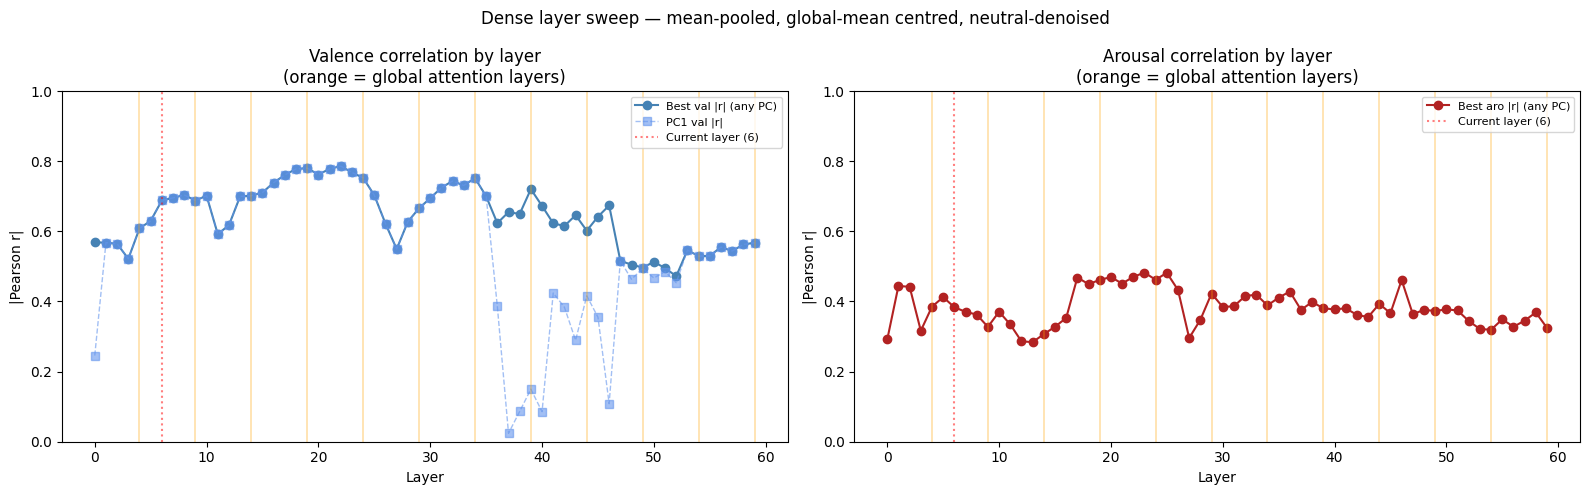

In [9]:
# ── Dense Layer Sweep ─────────────────────────────────────────────────────────
# Sweeps all 60 layers with global-mean centering + neutral PCA denoising.
# Shows where valence/arousal/dominance are best encoded.
#
# E2B finding context (for comparison):
#   E2B Phase 1 (last-token): valence peak at L25
#   E2B Phase 2 (mean-pool):  valence peak at L8
# 31B sparse sweep (Phase 2 mean-pool, every 6L): valence provisional L6 (r=+0.675),
#   arousal provisional L54 (|r|=0.416, trend still rising — true peak may be deeper).

# 31B: 60 layers, 4:1 sliding:full ratio, same pattern as E2B extended to 60L.
# Full attention (global) at every 5th layer starting at 4.
GLOBAL_LAYERS = [4, 9, 14, 19, 24, 29, 34, 39, 44, 49, 54, 59]  # Gemma 4 31B global layers

all_emotion_keys_sweep = [k for k in resid_acts.keys() if k != '__neutral__']
neutral_all = resid_acts['__neutral__']   # [100, n_layers, d_model]
n_lay = neutral_all.shape[1]

sweep_rows = []
for layer in range(n_lay):
    # Global-mean centred directions
    emot_means_l = np.stack([
        resid_acts[e][:, layer, :].mean(axis=0)
        for e in kept_names        # 171 emotions matched to NRC-VAD
    ])
    global_mean_l  = emot_means_l.mean(axis=0)
    dirs_l         = emot_means_l - global_mean_l

    # Neutral PCA denoising at this layer
    neutral_l   = neutral_all[:, layer, :]
    pca_n_l     = PCA()
    pca_n_l.fit(neutral_l)
    cumvar_n_l  = np.cumsum(pca_n_l.explained_variance_ratio_)
    n_pcs_l     = int(np.searchsorted(cumvar_n_l, VARIANCE_THRESHOLD) + 1)
    comps_l     = pca_n_l.components_[:n_pcs_l]
    dirs_den_l  = np.array([denoise_vec(d, comps_l) for d in dirs_l])

    # PCA on denoised directions
    n_comp = min(10, len(dirs_den_l) - 1)
    pca_l  = PCA(n_components=n_comp)
    sc_l   = pca_l.fit_transform(dirs_den_l)

    # PC1 correlations
    rv1, _ = stats.pearsonr(sc_l[:, 0], vad[:, 0])
    ra1, _ = stats.pearsonr(sc_l[:, 0], vad[:, 1])
    rd1, _ = stats.pearsonr(sc_l[:, 0], vad[:, 2])

    # Best PC for each VAD dimension (by |r|)
    def best_pc_r(dim_idx):
        rs = [abs(stats.pearsonr(sc_l[:, i], vad[:, dim_idx])[0]) for i in range(n_comp)]
        idx = int(np.argmax(rs))
        return idx + 1, rs[idx]

    bv_pc, bv_r = best_pc_r(0)
    ba_pc, ba_r = best_pc_r(1)

    sweep_rows.append(dict(
        layer=layer,
        ltype='GLOBAL' if layer in GLOBAL_LAYERS else 'local',
        pc1_var=pca_l.explained_variance_ratio_[0],
        pc1_val=rv1,
        pc1_aro=ra1,
        pc1_dom=rd1,
        best_val_pc=bv_pc, best_val_r=bv_r,
        best_aro_pc=ba_pc, best_aro_r=ba_r,
        n_neutral_pcs=n_pcs_l,
    ))

df_sweep = pd.DataFrame(sweep_rows)

# ── Print table ────────────────────────────────────────────────────────────────
print(f"{'Lay':>4}  {'type':>6}  {'PC1var%':>7}  "
      f"{'PC1 val_r':>10}  {'PC1 aro_r':>10}  "
      f"{'BestVal':>9}  {'BestAro':>9}  {'nNPCs':>5}")
for _, r in df_sweep.iterrows():
    marker = " ◄" if r.layer == LAYER else ""
    print(f"{int(r.layer):>4}  {r.ltype:>6}  {r.pc1_var*100:>6.1f}%  "
          f"{r.pc1_val:>+10.3f}  {r.pc1_aro:>+10.3f}  "
          f"PC{int(r.best_val_pc)} r={r.best_val_r:.3f}  "
          f"PC{int(r.best_aro_pc)} r={r.best_aro_r:.3f}  "
          f"{int(r.n_neutral_pcs):>5}{marker}")

# ── Report optimal layers ──────────────────────────────────────────────────────
best_val_idx = df_sweep['best_val_r'].idxmax()
best_aro_idx = df_sweep['best_aro_r'].idxmax()
print(f"\nBest valence layer: {int(df_sweep.loc[best_val_idx,'layer'])}  "
      f"PC{int(df_sweep.loc[best_val_idx,'best_val_pc'])} "
      f"r={df_sweep.loc[best_val_idx,'best_val_r']:.3f}")
print(f"Best arousal layer: {int(df_sweep.loc[best_aro_idx,'layer'])}  "
      f"PC{int(df_sweep.loc[best_aro_idx,'best_aro_pc'])} "
      f"r={df_sweep.loc[best_aro_idx,'best_aro_r']:.3f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(df_sweep['layer'], df_sweep['best_val_r'], 'o-', color='steelblue',
        label='Best val |r| (any PC)', linewidth=1.5)
ax.plot(df_sweep['layer'], df_sweep['pc1_val'].abs(), 's--', color='cornflowerblue',
        alpha=0.6, label='PC1 val |r|', linewidth=1)
for gl in GLOBAL_LAYERS:
    ax.axvline(gl, color='orange', alpha=0.35, linewidth=1.2)
ax.axvline(LAYER, color='red', alpha=0.5, linewidth=1.5, linestyle=':', label=f'Current layer ({LAYER})')
ax.set_xlabel('Layer'); ax.set_ylabel('|Pearson r|')
ax.set_title('Valence correlation by layer\n(orange = global attention layers)')
ax.legend(fontsize=8); ax.set_ylim(0, 1)

ax = axes[1]
ax.plot(df_sweep['layer'], df_sweep['best_aro_r'], 'o-', color='firebrick',
        label='Best aro |r| (any PC)', linewidth=1.5)
for gl in GLOBAL_LAYERS:
    ax.axvline(gl, color='orange', alpha=0.35, linewidth=1.2)
ax.axvline(LAYER, color='red', alpha=0.5, linewidth=1.5, linestyle=':', label=f'Current layer ({LAYER})')
ax.set_xlabel('Layer'); ax.set_ylabel('|Pearson r|')
ax.set_title('Arousal correlation by layer\n(orange = global attention layers)')
ax.legend(fontsize=8); ax.set_ylim(0, 1)

plt.suptitle('Dense layer sweep — mean-pooled, global-mean centred, neutral-denoised',
             fontsize=12)
plt.tight_layout()
plt.savefig('layer_sweep.png', dpi=150)
plt.show()


In [10]:
# ── Cell 7: Cumulative R² — which dimension is best explained? ───────────────
print(f"\n{'k':>4}  {'Valence R²':>11}  {'Arousal R²':>11}  {'Dominance R²':>13}  {'best':>8}")
for k in [1, 2, 3, 4, 5, 8, 10, 15, 20]:
    r2s = [
        sum(stats.pearsonr(scores[:, i], vad[:, j])[0]**2 for i in range(k))
        for j in range(3)
    ]
    best = dim_names[np.argmax(r2s)]
    print(f"{k:>4}  {r2s[0]:>11.3f}  {r2s[1]:>11.3f}  {r2s[2]:>13.3f}  {best:>8}")



   k   Valence R²   Arousal R²   Dominance R²      best
   1        0.474        0.049          0.276   valence
   2        0.484        0.058          0.282   valence
   3        0.498        0.095          0.295   valence
   4        0.526        0.095          0.334   valence
   5        0.644        0.096          0.349   valence
   8        0.660        0.345          0.460   valence
  10        0.684        0.452          0.462   valence
  15        0.700        0.542          0.568   valence
  20        0.728        0.575          0.610   valence


In [11]:
# ── Cell 8: What emotions drive each PC? ────────────────────────────────────
N_TOP = 6
for i in range(6):
    s = scores[:, i]
    pos = np.argsort(s)[-N_TOP:][::-1]
    neg = np.argsort(s)[:N_TOP]
    r_v, _ = stats.pearsonr(s, vad[:, 0])
    r_a, _ = stats.pearsonr(s, vad[:, 1])
    r_d, _ = stats.pearsonr(s, vad[:, 2])
    print(f"\nPC{i+1}  ({pca.explained_variance_ratio_[i]*100:.1f}% var)  "
          f"V={r_v:+.3f}  A={r_a:+.3f}  D={r_d:+.3f}")
    print(f"  +: {', '.join(kept_names[j] for j in pos)}")
    print(f"  −: {', '.join(kept_names[j] for j in neg)}")


PC1  (14.1% var)  V=+0.688  A=-0.221  D=+0.525
  +: happy, relaxed, cheerful, content, delighted, grateful
  −: hysterical, overwhelmed, distressed, miserable, rattled, dependent

PC2  (8.9% var)  V=-0.102  A=-0.096  D=-0.075
  +: shocked, fulfilled, embarrassed, joyful, panicked, disturbed
  −: happy, pleased, elated, euphoric, triumphant, self_confident

PC3  (6.8% var)  V=-0.117  A=-0.192  D=-0.117
  +: jealous, remorseful, obstinate, gloomy, loving, empathetic
  −: happy, pleased, ecstatic, relaxed, surprised, frustrated

PC4  (6.5% var)  V=-0.169  A=+0.024  D=-0.196
  +: relaxed, happy, alert, trapped, aroused, mortified
  −: indifferent, offended, amazed, grumpy, stubborn, refreshed

PC5  (4.4% var)  V=-0.343  A=+0.011  D=-0.125
  +: stubborn, vengeful, obstinate, impatient, happy, humiliated
  −: joyful, refreshed, proud, grateful, aroused, sensitive

PC6  (3.7% var)  V=-0.122  A=-0.314  D=-0.192
  +: pleased, heartbroken, calm, gloomy, relieved, listless
  −: enthusiastic, che

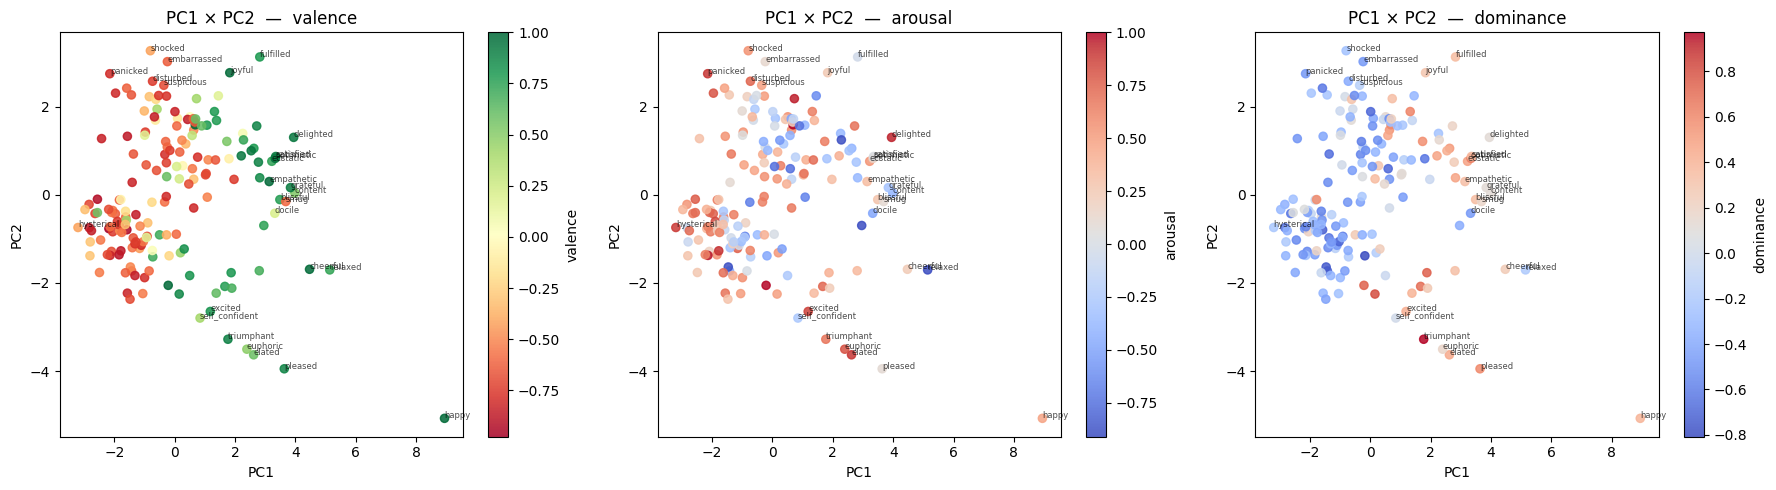

In [12]:
# ── Cell 9: Scatter plots — PC1×PC2 coloured by V, A, D ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (j, dim) in zip(axes, enumerate(dim_names)):
    sc = ax.scatter(scores[:, 0], scores[:, 1],
                    c=vad[:, j], cmap='RdYlGn' if dim == 'valence' else 'coolwarm',
                    s=35, alpha=0.85)
    plt.colorbar(sc, ax=ax, label=dim)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'PC1 × PC2  —  {dim}')
    thresh = 1.6 * scores[:, :2].std(axis=0)
    for name, s_row in zip(kept_names, scores):
        if abs(s_row[0]) > thresh[0] or abs(s_row[1]) > thresh[1]:
            ax.annotate(name, (s_row[0], s_row[1]), fontsize=6, alpha=0.7)
plt.tight_layout()
plt.savefig('pc1pc2_vad.png', dpi=150)
plt.show()

In [13]:
# ── Cell 10: Compute per-emotion power scores ─────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

norms = np.linalg.norm(dirs_denoised, axis=1)                    # [N]
valence_extremity = np.abs(vad[:, 0] - 0.5)            # [N]  NRC valence is 0–1, neutral at 0.5

cos_matrix = cosine_similarity(dirs_denoised)                     # [N, N]
np.fill_diagonal(cos_matrix, -1)                         # ignore self
max_cosine = cos_matrix.max(axis=1)                      # [N] — nearest neighbour similarity

power = norms * valence_extremity * (1.0 / (max_cosine + 1e-6))

# Summary: what drives power?
for name, n, v, mc, p in sorted(
        zip(kept_names, norms, valence_extremity, max_cosine, power),
        key=lambda x: -x[4])[:20]:
    print(f"{name:<30}  norm={n:.2f}  |v-0.5|={v:.3f}  max_cos={mc:.3f}  power={p:.2f}")


heartbroken                     norm=6.52  |v-0.5|=1.336  max_cos=0.463  power=18.84
dumbstruck                      norm=5.83  |v-0.5|=1.000  max_cos=0.330  power=17.66
grief_stricken                  norm=5.31  |v-0.5|=1.360  max_cos=0.426  power=16.96
scornful                        norm=5.42  |v-0.5|=1.154  max_cos=0.378  power=16.53
impatient                       norm=5.59  |v-0.5|=1.000  max_cos=0.339  power=16.52
obstinate                       norm=6.29  |v-0.5|=1.208  max_cos=0.460  power=16.51
annoyed                         norm=4.73  |v-0.5|=1.292  max_cos=0.378  power=16.17
worthless                       norm=4.37  |v-0.5|=1.334  max_cos=0.368  power=15.83
frustrated                      norm=6.01  |v-0.5|=1.340  max_cos=0.512  power=15.72
paranoid                        norm=4.83  |v-0.5|=1.256  max_cos=0.388  power=15.63
spiteful                        norm=4.57  |v-0.5|=1.354  max_cos=0.402  power=15.40
humiliated                      norm=4.66  |v-0.5|=1.292  max_cos

In [14]:
# ── Cell 11: Select top-N per valence pole ────────────────────────────────────
def select_emotional_range(kept_names, dirs, vad, power, n_per_pole=15):
    pos_mask = vad[:, 0] > 0.5   # positive valence
    neg_mask = vad[:, 0] < 0.5   # negative valence

    def top_n(mask, n):
        idx = np.where(mask)[0]
        ranked = sorted(idx, key=lambda i: -power[i])
        return ranked[:n]

    pos_idx = top_n(pos_mask, n_per_pole)
    neg_idx = top_n(neg_mask, n_per_pole)
    selected = pos_idx + neg_idx

    print(f"\nPositive pole ({n_per_pole}):")
    for i in pos_idx:
        print(f"  {kept_names[i]:<30}  valence={vad[i,0]:.3f}  power={power[i]:.2f}")
    print(f"\nNegative pole ({n_per_pole}):")
    for i in neg_idx:
        print(f"  {kept_names[i]:<30}  valence={vad[i,0]:.3f}  power={power[i]:.2f}")

    return selected

selected_idx = select_emotional_range(kept_names, dirs_denoised, vad, power, n_per_pole=15)


Positive pole (15):
  happy                           valence=0.985  power=10.64
  cheerful                        valence=0.990  power=6.71
  joyful                          valence=0.990  power=6.58
  empathetic                      valence=1.000  power=6.45
  invigorated                     valence=1.000  power=5.82
  optimistic                      valence=0.958  power=5.39
  hopeful                         valence=0.894  power=5.32
  fulfilled                       valence=0.792  power=5.30
  pleased                         valence=0.878  power=5.25
  amused                          valence=0.884  power=5.06
  delighted                       valence=0.938  power=4.95
  exuberant                       valence=1.000  power=4.66
  excited                         valence=0.816  power=4.65
  enthusiastic                    valence=0.770  power=4.57
  refreshed                       valence=0.820  power=4.54

Negative pole (15):
  heartbroken                     valence=-0.836  power=1

In [15]:
# ── Cell 12: PCA and VAD correlations on emotional range subset ───────────────
def range_pca_analysis(selected_idx, n_pcs=10, label=""):
    sel_dirs = dirs_denoised[selected_idx]
    sel_vad  = vad[selected_idx]
    sel_names = [kept_names[i] for i in selected_idx]
    N_sel = len(selected_idx)

    pca_r = PCA(n_components=min(n_pcs, N_sel))
    scores_r = pca_r.fit_transform(sel_dirs)

    print(f"\n── {label} (N={N_sel}) ──")
    print(f"{'PC':>4}  {'var%':>6}  {'valence_r':>10}  {'arousal_r':>10}  {'dominance_r':>12}")
    for i in range(min(n_pcs, N_sel)):
        rv, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 0])
        ra, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 1])
        rd, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 2])
        print(f"{i+1:>4}  {pca_r.explained_variance_ratio_[i]*100:>5.1f}%"
              f"  {rv:>+10.3f}  {ra:>+10.3f}  {rd:>+12.3f}")

    # Cumulative R² for valence
    cum_r2_v = sum(stats.pearsonr(scores_r[:, i], sel_vad[:, 0])[0]**2
                   for i in range(min(5, N_sel)))
    print(f"\n  Valence R² (top-5 PCs combined): {cum_r2_v:.3f}  → r={cum_r2_v**0.5:.3f}")
    return pca_r, scores_r, sel_names

# Try different N values
for n in [10, 15, 20]:
    idx = select_emotional_range(kept_names, dirs_denoised, vad, power, n_per_pole=n)
    range_pca_analysis(idx, label=f"Top-{n} per pole")


Positive pole (10):
  happy                           valence=0.985  power=10.64
  cheerful                        valence=0.990  power=6.71
  joyful                          valence=0.990  power=6.58
  empathetic                      valence=1.000  power=6.45
  invigorated                     valence=1.000  power=5.82
  optimistic                      valence=0.958  power=5.39
  hopeful                         valence=0.894  power=5.32
  fulfilled                       valence=0.792  power=5.30
  pleased                         valence=0.878  power=5.25
  amused                          valence=0.884  power=5.06

Negative pole (10):
  heartbroken                     valence=-0.836  power=18.84
  dumbstruck                      valence=-0.500  power=17.66
  grief_stricken                  valence=-0.860  power=16.96
  scornful                        valence=-0.654  power=16.53
  impatient                       valence=-0.500  power=16.52
  obstinate                       valence=-0.70

In [16]:
# ── Tri-polar selection ───────────────────────────────────────────────────────
# Requires: kept_names, dirs, vad, norms, max_cosine (all from Cells 3-10)
# NRC-VAD valence is in [-1, 1]; neutral ≈ 0

def select_tri_polar_emotions(kept_names, dirs, vad, norms, max_cosine,
                               n_per_pole=10, neutral_band=0.25):
    """
    Positive/negative poles: existing power score (consistent with Cell 10/11).
    Neutral pole: norm × distinctiveness, filtered to |valence| < neutral_band.
    """
    valence_extremity = np.abs(vad[:, 0] - 0.5)  # same formula as Cell 10
    power_full = norms * valence_extremity * (1.0 / (max_cosine + 1e-6))
    neutral_power = norms * (1.0 / (max_cosine + 1e-6))  # no valence term

    pos_idx = np.where(vad[:, 0] > 0.5)[0]
    pos_idx = pos_idx[np.argsort(-power_full[pos_idx])][:n_per_pole]

    neg_idx = np.where(vad[:, 0] < -0.5)[0]  # symmetric: clearly negative
    neg_idx = neg_idx[np.argsort(-power_full[neg_idx])][:n_per_pole]

    neutral_idx = np.where(np.abs(vad[:, 0]) < neutral_band)[0]
    neutral_idx = neutral_idx[np.argsort(-neutral_power[neutral_idx])][:n_per_pole]

    print(f"\nPositive pole ({len(pos_idx)}):")
    for i in pos_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  power={power_full[i]:.2f}")
    print(f"\nNeutral pole ({len(neutral_idx)}, |v|<{neutral_band}):")
    for i in neutral_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  neutral_power={neutral_power[i]:.2f}")
    print(f"\nNegative pole ({len(neg_idx)}):")
    for i in neg_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  power={power_full[i]:.2f}")

    return {'positive': pos_idx.tolist(), 'neutral': neutral_idx.tolist(),
            'negative': neg_idx.tolist()}


def run_tripolar_pca(selected, kept_names, dirs, vad, n_pcs=5):
    pole_names = ['positive', 'neutral', 'negative']
    colours = {'positive': 'steelblue', 'negative': 'firebrick', 'neutral': 'goldenrod'}
    markers  = {'positive': '^', 'negative': 'v', 'neutral': 'o'}

    all_idx = selected['positive'] + selected['neutral'] + selected['negative']
    labels  = (
        ['positive'] * len(selected['positive']) +
        ['neutral']  * len(selected['neutral']) +
        ['negative'] * len(selected['negative'])
    )
    sel_dirs  = dirs[all_idx]
    sel_vad   = vad[all_idx]
    sel_names = [kept_names[i] for i in all_idx]

    pca_t    = PCA(n_components=min(n_pcs, len(all_idx)))
    scores_t = pca_t.fit_transform(sel_dirs)

    print(f"\n── Tri-polar PCA (N={len(all_idx)}) ──")
    print(f"{'PC':>4}  {'var%':>6}  {'valence_r':>10}  {'arousal_r':>10}  {'dominance_r':>12}")
    for i in range(pca_t.n_components_):
        rv, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 0])
        ra, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 1])
        rd, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 2])
        print(f"{i+1:>4}  {pca_t.explained_variance_ratio_[i]*100:>5.1f}%"
              f"  {rv:>+10.3f}  {ra:>+10.3f}  {rd:>+12.3f}")

    # PC1×PC2 and PC2×PC3 — shape = pole, colour = arousal
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    arousals = sel_vad[:, 1]
    for ax, (xpc, ypc) in zip(axes, [(0, 1), (1, 2)]):
        for pole in pole_names:
            idx = [i for i, l in enumerate(labels) if l == pole]
            sc = ax.scatter(
                scores_t[idx, xpc], scores_t[idx, ypc],
                c=arousals[idx], cmap='RdYlBu_r', vmin=-1, vmax=1,
                marker=markers[pole], s=90, edgecolors=colours[pole],
                linewidths=1.5, label=pole, zorder=3,
            )
            for i in idx:
                ax.annotate(sel_names[i], (scores_t[i, xpc], scores_t[i, ypc]),
                            fontsize=7, alpha=0.75, ha='center', va='bottom')
        plt.colorbar(sc, ax=ax, label='Arousal')
        ax.set_xlabel(f'PC{xpc+1}'); ax.set_ylabel(f'PC{ypc+1}')
        ax.legend()
    axes[0].set_title('PC1 vs PC2 — shape=pole, colour=arousal')
    axes[1].set_title('PC2 vs PC3 — shape=pole, colour=arousal')
    plt.suptitle(f'Tri-polar emotional range — n={len(selected["positive"])} per pole', fontsize=12)
    plt.tight_layout()
    plt.savefig('tripolar_pca.png', dpi=150)
    plt.show()
    return scores_t, pca_t


Neutral band coverage (valence in [-1,1], neutral=0):
  |v|<0.15:   8 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.20:  12 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.25:  18 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.30:  20 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)

============================================================  n_per_pole=8

Positive pole (8):
  happy                           v=+0.985  power=10.64
  cheerful                        v=+0.990  power=6.71
  joyful                          v=+0.990  power=6.58
  empathetic                      v=+1.000  power=6.45
  invigorated                     v=+1.000  power=5.82
  optimistic                      v=+0.958  power=5.39
  hopeful              

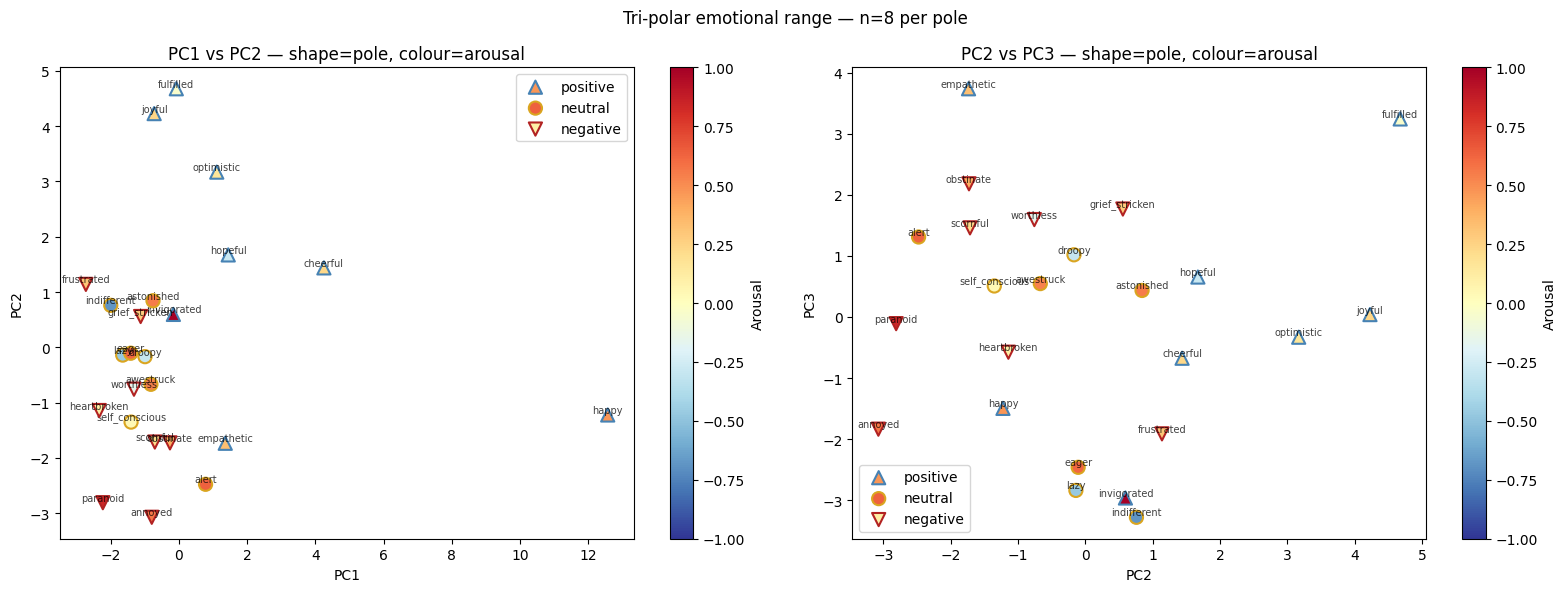


============================================================  n_per_pole=10

Positive pole (10):
  happy                           v=+0.985  power=10.64
  cheerful                        v=+0.990  power=6.71
  joyful                          v=+0.990  power=6.58
  empathetic                      v=+1.000  power=6.45
  invigorated                     v=+1.000  power=5.82
  optimistic                      v=+0.958  power=5.39
  hopeful                         v=+0.894  power=5.32
  fulfilled                       v=+0.792  power=5.30
  pleased                         v=+0.878  power=5.25
  amused                          v=+0.884  power=5.06

Neutral pole (10, |v|<0.25):
  alert                           v=-0.042  neutral_power=15.13
  lazy                            v=-0.216  neutral_power=14.57
  awestruck                       v=+0.230  neutral_power=13.59
  eager                           v=+0.042  neutral_power=13.38
  indifferent                     v=-0.208  neutral_power=12.99
 

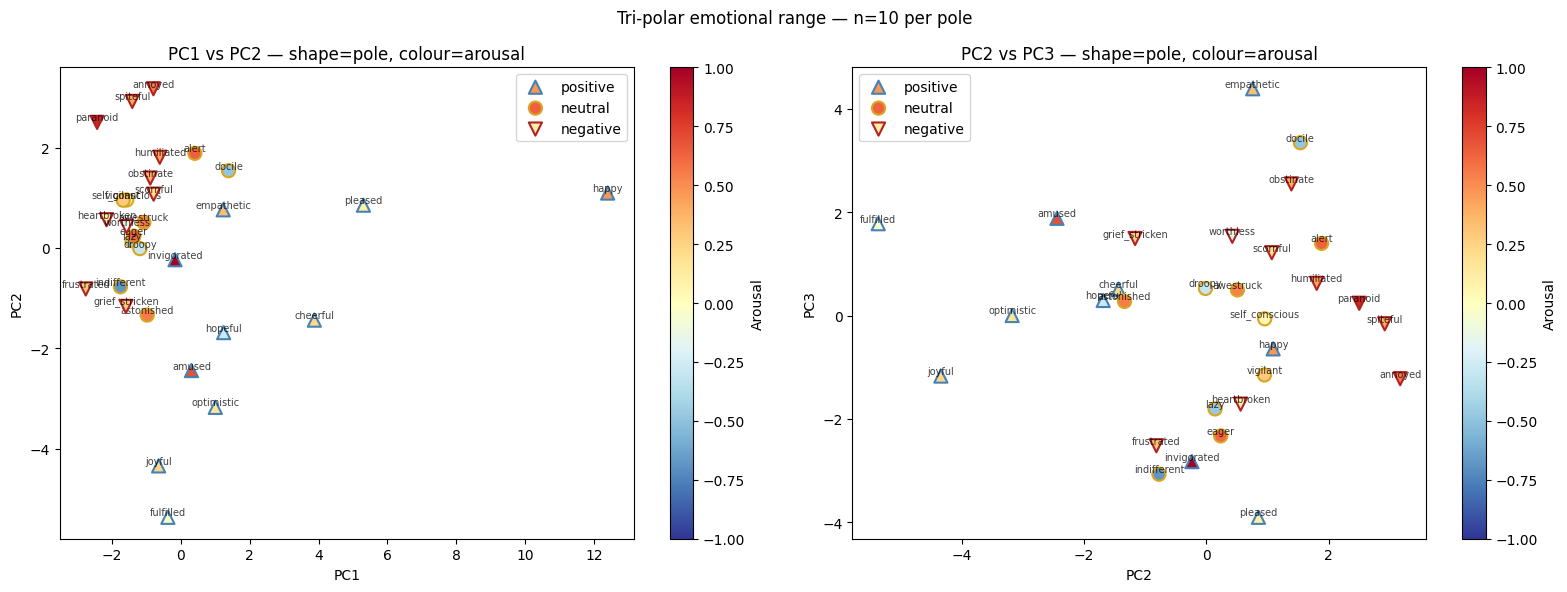


============================================================  n_per_pole=12

Positive pole (12):
  happy                           v=+0.985  power=10.64
  cheerful                        v=+0.990  power=6.71
  joyful                          v=+0.990  power=6.58
  empathetic                      v=+1.000  power=6.45
  invigorated                     v=+1.000  power=5.82
  optimistic                      v=+0.958  power=5.39
  hopeful                         v=+0.894  power=5.32
  fulfilled                       v=+0.792  power=5.30
  pleased                         v=+0.878  power=5.25
  amused                          v=+0.884  power=5.06
  delighted                       v=+0.938  power=4.95
  exuberant                       v=+1.000  power=4.66

Neutral pole (12, |v|<0.25):
  alert                           v=-0.042  neutral_power=15.13
  lazy                            v=-0.216  neutral_power=14.57
  awestruck                       v=+0.230  neutral_power=13.59
  eager            

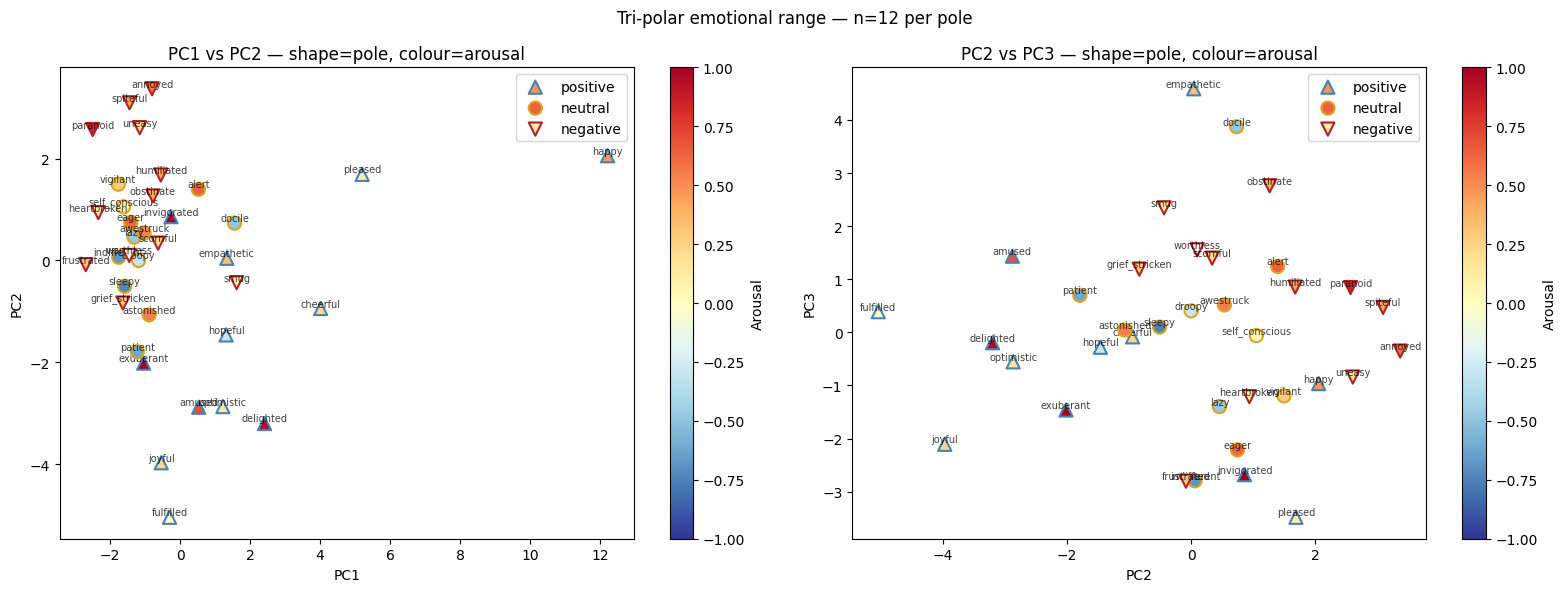

In [17]:
# ── Exercise ──────────────────────────────────────────────────────────────────

# First: check how many emotions fall in the neutral band at each threshold
print("Neutral band coverage (valence in [-1,1], neutral=0):")
for band in [0.15, 0.20, 0.25, 0.30]:
    in_band = [(kept_names[i], vad[i, 0]) for i in range(len(kept_names))
               if abs(vad[i, 0]) < band]
    preview = ', '.join(f"{n}({v:+.2f})" for n, v in
                        sorted(in_band, key=lambda x: abs(x[1]))[:6])
    print(f"  |v|<{band:.2f}: {len(in_band):3d} emotions — {preview}")

# Run at a few N values
for n in [8, 10, 12]:
    print(f"\n{'='*60}  n_per_pole={n}")
    selected = select_tri_polar_emotions(
        kept_names, dirs_denoised, vad, norms, max_cosine,
        n_per_pole=n, neutral_band=0.25,
    )
    run_tripolar_pca(selected, kept_names, dirs_denoised, vad)

---
## Arousal Analysis

Dense sweep will identify the arousal-optimal layer. Provisional value from Phase 2
sparse sweep: L54 (|r|=0.416, trend still rising — true peak may be at L57–59).
E2B arousal peak was L25. This section reruns the full PCA pipeline at the arousal
layer to characterise the arousal structure: per-PC correlations, cumulative R²,
dominant emotion loadings, and an arousal bipolar subset to test whether a clean
arousal axis emerges under selection.

*Update ARO_LAYER in Cell 18 to the dense-sweep optimal layer before running this section.*


In [18]:
# ── Arousal A: recompute directions at arousal-optimal layer ──────────────────
# Dense sweep confirmed L23 (PC2 r=0.482); co-localised with valence peak at L22.
ARO_LAYER = 23  # Confirmed: 31B arousal-optimal (dense sweep PC2 r=0.482, co-localised with valence at L22)

# Mean activations at layer 25 for the 171 NRC-matched emotions
aro_emo_means = np.stack([
    resid_acts[name][:, ARO_LAYER, :].mean(axis=0)
    for name in kept_names
])  # [171, d_model]

aro_global_mean = aro_emo_means.mean(axis=0)
aro_dirs_raw = aro_emo_means - aro_global_mean  # [171, d_model]

# Neutral denoising at layer 25 (same VARIANCE_THRESHOLD=0.50 as main analysis)
neutral_raw_aro = neutral_stories[:, ARO_LAYER, :]
pca_n_aro = PCA()
pca_n_aro.fit(neutral_raw_aro)
cumvar_n_aro = np.cumsum(pca_n_aro.explained_variance_ratio_)
n_n_aro = int(np.searchsorted(cumvar_n_aro, VARIANCE_THRESHOLD) + 1)
comps_aro = pca_n_aro.components_[:n_n_aro]

aro_dirs = np.array([denoise_vec(d, comps_aro) for d in aro_dirs_raw])

print(f"Arousal analysis layer: {ARO_LAYER}")
print(f"Directions: {aro_dirs.shape}")
print(f"Neutral denoising: {n_n_aro} PCs → {cumvar_n_aro[n_n_aro-1]*100:.1f}% neutral variance")

Arousal analysis layer: 54
Directions: (171, 5376)
Neutral denoising: 31 PCs → 50.1% neutral variance


In [19]:
# ── Arousal B: PCA + per-PC NRC-VAD correlations at layer 25 ─────────────────
N_PCS_ARO = 50
pca_aro = PCA(n_components=N_PCS_ARO)
scores_aro = pca_aro.fit_transform(aro_dirs)  # [171, 50]

cumvar_aro = np.cumsum(pca_aro.explained_variance_ratio_)
print(f"Variance explained at layer {ARO_LAYER}:")
for k in [1, 3, 5, 10, 20, 36]:
    print(f"  {k:2d} PCs → {cumvar_aro[k-1]*100:.1f}%")

print(f"\nLayer {ARO_LAYER} per-PC correlations with NRC-VAD (top 20 PCs):")
rows_aro = []
for i in range(20):
    row = {'PC': i+1, 'var%': f"{pca_aro.explained_variance_ratio_[i]*100:.1f}"}
    for j, dim in enumerate(['valence', 'arousal', 'dominance']):
        r, p = stats.pearsonr(scores_aro[:, i], vad[:, j])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        row[f'{dim}_r'] = f"{r:+.3f}{sig}"
    rows_aro.append(row)

print(pd.DataFrame(rows_aro).set_index('PC').to_string())

Variance explained at layer 54:
   1 PCs → 12.0%
   3 PCs → 26.6%
   5 PCs → 34.9%
  10 PCs → 45.9%
  20 PCs → 57.4%
  36 PCs → 68.2%

Layer 54 per-PC correlations with NRC-VAD (top 20 PCs):
    var%  valence_r  arousal_r dominance_r
PC                                        
1   12.0  -0.530***  +0.299***   -0.360***
2    9.1  -0.403***  -0.300***   -0.425***
3    5.5  +0.309***   -0.213**      +0.070
4    4.8     -0.122    +0.171*      -0.117
5    3.5  +0.251***     +0.034   +0.290***
6    3.0     +0.129  -0.284***      -0.127
7    2.4   -0.218**  -0.319***    -0.236**
8    2.2     -0.034     +0.136      +0.056
9    1.7     -0.019     +0.051      +0.043
10   1.6     -0.020  +0.270***      -0.029
11   1.5     -0.013    -0.196*   -0.257***
12   1.4     -0.038     -0.147      -0.118
13   1.3     +0.062     -0.111      -0.108
14   1.3     -0.037     -0.065      -0.130
15   1.2     -0.041     -0.056     -0.164*
16   1.1     -0.031     +0.038      -0.087
17   1.0     -0.044     +0.005     

In [20]:
# ── Arousal C: Cumulative R² at layer 25 ─────────────────────────────────────
print(f"Cumulative R² at layer {ARO_LAYER} (arousal-optimal):")
print(f"{'k':>4}  {'Valence R²':>11}  {'Arousal R²':>11}  {'Dominance R²':>13}  {'best':>9}")
for k in [1, 2, 3, 4, 5, 8, 10, 15, 20]:
    r2s = [
        sum(stats.pearsonr(scores_aro[:, i], vad[:, j])[0]**2 for i in range(k))
        for j in range(3)
    ]
    best = ['valence', 'arousal', 'dominance'][np.argmax(r2s)]
    print(f"{k:>4}  {r2s[0]:>11.3f}  {r2s[1]:>11.3f}  {r2s[2]:>13.3f}  {best:>9}")

Cumulative R² at layer 54 (arousal-optimal):
   k   Valence R²   Arousal R²   Dominance R²       best
   1        0.280        0.089          0.129    valence
   2        0.443        0.179          0.310    valence
   3        0.538        0.225          0.315    valence
   4        0.553        0.254          0.328    valence
   5        0.616        0.255          0.413    valence
   8        0.681        0.456          0.487    valence
  10        0.682        0.532          0.490    valence
  15        0.691        0.612          0.625    valence
  20        0.710        0.637          0.638    valence


In [21]:
# ── Arousal D: dominant emotion loadings for arousal-predictive PCs ──────────
aro_pc_cors = [abs(stats.pearsonr(scores_aro[:, i], vad[:, 1])[0]) for i in range(15)]
top_aro_pcs = sorted(range(15), key=lambda i: -aro_pc_cors[i])[:4]

print(f"Top 4 arousal-predictive PCs at layer {ARO_LAYER}:")
for idx in top_aro_pcs:
    r_a, _ = stats.pearsonr(scores_aro[:, idx], vad[:, 1])
    r_v, _ = stats.pearsonr(scores_aro[:, idx], vad[:, 0])
    r_d, _ = stats.pearsonr(scores_aro[:, idx], vad[:, 2])
    var_pct = pca_aro.explained_variance_ratio_[idx] * 100
    print(f"\nPC{idx+1} ({var_pct:.1f}% var)  val={r_v:+.3f}  aro={r_a:+.3f}  dom={r_d:+.3f}")
    s = scores_aro[:, idx]
    top_idx = np.argsort(s)[-8:][::-1]
    bot_idx = np.argsort(s)[:8]
    print(f"  + pole: {', '.join(kept_names[j] for j in top_idx)}")
    print(f"  − pole: {', '.join(kept_names[j] for j in bot_idx)}")

Top 4 arousal-predictive PCs at layer 54:

PC7 (2.4% var)  val=-0.218  aro=-0.319  dom=-0.236
  + pole: stubborn, lazy, calm, obstinate, serene, grumpy, resigned, furious
  − pole: thrilled, hysterical, hopeful, aroused, ecstatic, joyful, fulfilled, restless

PC2 (9.1% var)  val=-0.403  aro=-0.300  dom=-0.425
  + pole: correction_discomfort, guilty, grief_stricken, resigned, sensitive, droopy, weary, unhappy
  − pole: cheerful, optimistic, happy, delighted, pleased, euphoric, jubilant, elated

PC1 (12.0% var)  val=-0.530  aro=+0.299  dom=-0.360
  + pole: hysterical, bitter, outraged, exasperated, enraged, surprised, rattled, indifferent
  − pole: grateful, happy, peaceful, blissful, safe, relaxed, content, at_ease

PC6 (3.0% var)  val=+0.129  aro=-0.284  dom=-0.127
  + pole: amazed, joyful, lazy, frustrated, surprised, serene, outraged, relieved
  − pole: happy, obstinate, excited, enthusiastic, vengeful, greedy, cheerful, valiant


In [22]:
# ── Arousal E: arousal bipolar subset ─────────────────────────────────────────
# Select top-N highest and lowest NRC-VAD arousal emotions; run PCA on subset.
# Tests whether a clean arousal axis emerges at layer 25 under selection
# (analogous to the valence bipolar subset which achieved r=0.846 at layer 8).

N_POLE_ARO = 15

aro_vals = vad[:, 1]  # NRC-VAD arousal scores
top_aro_idx = np.argsort(aro_vals)[-N_POLE_ARO:]   # high arousal
bot_aro_idx = np.argsort(aro_vals)[:N_POLE_ARO]    # low arousal
aro_sub_idx = np.concatenate([top_aro_idx, bot_aro_idx])

print(f"High-arousal (N={N_POLE_ARO}): {[kept_names[i] for i in top_aro_idx]}")
print(f"Low-arousal  (N={N_POLE_ARO}): {[kept_names[i] for i in bot_aro_idx]}")

dirs_aro_sub = aro_dirs[aro_sub_idx]
vad_aro_sub  = vad[aro_sub_idx]

pca_aro_sub = PCA(n_components=min(10, len(aro_sub_idx) - 1))
scores_aro_sub = pca_aro_sub.fit_transform(dirs_aro_sub)

print(f"\nArousal bipolar subset PCA (N={len(aro_sub_idx)}, layer {ARO_LAYER}):")
for i in range(min(5, pca_aro_sub.n_components_)):
    r_v, _ = stats.pearsonr(scores_aro_sub[:, i], vad_aro_sub[:, 0])
    r_a, p_a = stats.pearsonr(scores_aro_sub[:, i], vad_aro_sub[:, 1])
    r_d, _ = stats.pearsonr(scores_aro_sub[:, i], vad_aro_sub[:, 2])
    sig = '***' if p_a < 0.001 else '**' if p_a < 0.01 else '*' if p_a < 0.05 else ''
    var_pct = pca_aro_sub.explained_variance_ratio_[i] * 100
    print(f"  PC{i+1} ({var_pct:.1f}% var): val={r_v:+.3f}  aro={r_a:+.3f}{sig}  dom={r_d:+.3f}")

# Cumulative arousal R²
for k in [1, 3, 5]:
    r2_a = sum(stats.pearsonr(scores_aro_sub[:, i], vad_aro_sub[:, 1])[0]**2
               for i in range(min(k, pca_aro_sub.n_components_)))
    print(f"  k={k} PCs: arousal R²={r2_a:.3f} → r={r2_a**0.5:.3f}")

High-arousal (N=15): ['hostile', 'horrified', 'terrified', 'euphoric', 'paranoid', 'excited', 'hysterical', 'elated', 'panicked', 'furious', 'delighted', 'aroused', 'enraged', 'exuberant', 'invigorated']
Low-arousal  (N=15): ['relaxed', 'calm', 'peaceful', 'dumbstruck', 'sluggish', 'sleepy', 'serene', 'indifferent', 'bored', 'resigned', 'patient', 'lonely', 'kind', 'docile', 'melancholy']

Arousal bipolar subset PCA (N=30, layer 54):
  PC1 (18.1% var): val=+0.203  aro=-0.612***  dom=-0.268
  PC2 (11.8% var): val=-0.664  aro=-0.126  dom=-0.538
  PC3 (7.4% var): val=-0.127  aro=+0.180  dom=-0.109
  PC4 (6.7% var): val=-0.188  aro=+0.427*  dom=+0.233
  PC5 (5.4% var): val=-0.124  aro=-0.032  dom=+0.041
  k=1 PCs: arousal R²=0.374 → r=0.612
  k=3 PCs: arousal R²=0.423 → r=0.650
  k=5 PCs: arousal R²=0.606 → r=0.778


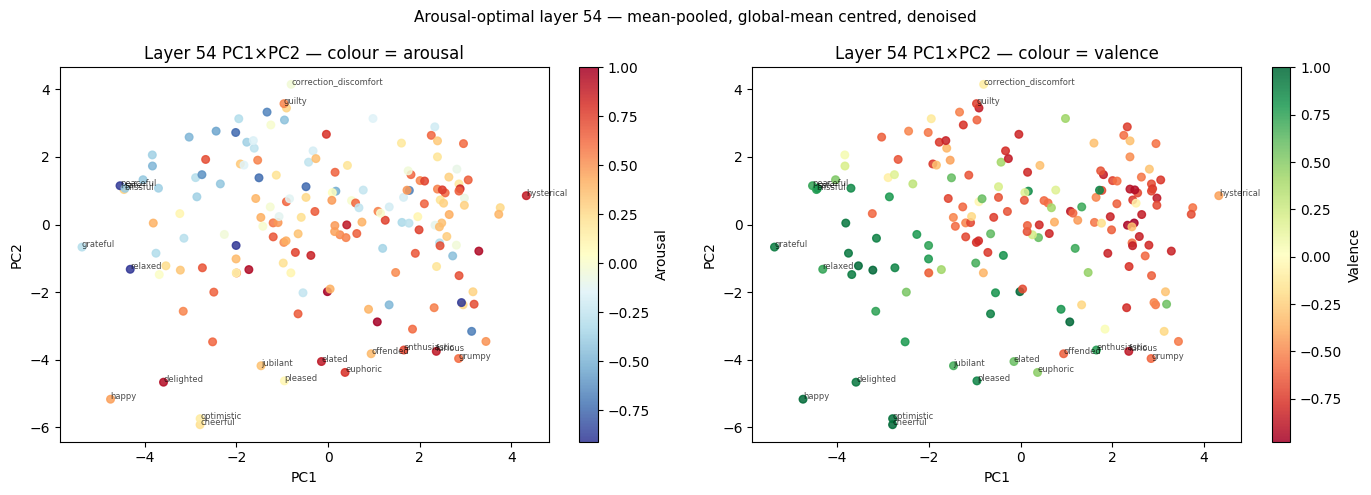

In [23]:
# ── Arousal F: scatter PC1 × PC2 at layer 25, coloured by arousal / valence ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

thresh_aro = 1.8 * scores_aro[:, :2].std(axis=0)

ax = axes[0]
sc = ax.scatter(scores_aro[:, 0], scores_aro[:, 1],
                c=vad[:, 1], cmap='RdYlBu_r', s=30, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Arousal')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Layer {ARO_LAYER} PC1×PC2 — colour = arousal')
for name, s_row in zip(kept_names, scores_aro):
    if abs(s_row[0]) > thresh_aro[0] or abs(s_row[1]) > thresh_aro[1]:
        ax.annotate(name, (s_row[0], s_row[1]), fontsize=6, alpha=0.7)

ax = axes[1]
sc = ax.scatter(scores_aro[:, 0], scores_aro[:, 1],
                c=vad[:, 0], cmap='RdYlGn', s=30, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Valence')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Layer {ARO_LAYER} PC1×PC2 — colour = valence')
for name, s_row in zip(kept_names, scores_aro):
    if abs(s_row[0]) > thresh_aro[0] or abs(s_row[1]) > thresh_aro[1]:
        ax.annotate(name, (s_row[0], s_row[1]), fontsize=6, alpha=0.7)

plt.suptitle(f'Arousal-optimal layer {ARO_LAYER} — mean-pooled, global-mean centred, denoised',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'layer_{ARO_LAYER}_aro_pca.png', dpi=150)
plt.show()